In [1]:
from ultralytics import YOLO
import os
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import torch
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

# Testing on Normal Images (False Positive Analysis)

此 notebook 測試模型在 **正常圖片（無結節）** 上的表現，  
主要關注 **False Positive (FP)** 情況：  
模型是否在沒有結節的圖片上誤判出結節。

| 情況 | 說明 |
|------|------|
| **TN** | 正確：模型未在正常圖片上預測出結節 |
| **FP** | 錯誤：模型在正常圖片上誤判出結節 |

主要指標：
- **Specificity** = TN images / (TN + FP images)（圖片層級）
- **FP rate** = images with FP / total normal images
- **Average FP per image**（整體）
- **Average FP per image**（只看有 FP 的圖片）

# Helper functions

In [2]:
def get_fp_records_normal(result, image_path, patient_id):
    """
    針對 normal 圖片（無 GT 標註），回傳每張圖片的預測記錄。

    - 所有 class 0 (nodule) 的預測框 -> FP
    - 無預測框 -> TN

    每筆 record 包含:
      patient_ID, file_name, match_type ('FP'/'TN'), pred_box, conf
    """
    file_name = Path(image_path).name
    base = {'patient_ID': patient_id, 'file_name': file_name}

    pred_boxes, pred_classes, pred_confs = [], [], []
    if result.boxes is not None and len(result.boxes) > 0:
        pred_boxes   = result.boxes.xyxy.cpu().numpy()
        pred_classes = result.boxes.cls.cpu().numpy()
        pred_confs   = result.boxes.conf.cpu().numpy()

    # 只看 class 0 (nodule)
    nodule_pred_idx = [i for i, cls in enumerate(pred_classes) if cls == 0]

    records = []
    if len(nodule_pred_idx) == 0:
        # 正確：沒有預測出結節
        records.append({**base,
            'match_type': 'TN',
            'pred_box': None,
            'conf': None,
        })
    else:
        # 錯誤：誤判出結節
        for i in nodule_pred_idx:
            records.append({**base,
                'match_type': 'FP',
                'pred_box': pred_boxes[i].tolist(),
                'conf': float(pred_confs[i]),
            })

    return records

In [3]:
def compute_normal_metrics(normal_df):
    """
    計算正常圖片的 FP 分析指標（圖片層級 & 病患層級）。
    """
    total_images   = normal_df['file_name'].nunique()
    total_patients = normal_df['patient_ID'].nunique()

    # 圖片層級
    fp_images = normal_df[normal_df['match_type'] == 'FP']['file_name'].nunique()
    tn_images = total_images - fp_images
    specificity  = tn_images / total_images
    fp_rate      = fp_images / total_images

    total_fp = (normal_df['match_type'] == 'FP').sum()
    avg_fp_per_image_overall = total_fp / total_images
    avg_fp_per_fp_image = total_fp / fp_images if fp_images > 0 else 0

    # 病患層級：有任何 FP 圖片的病患
    fp_patient_ids = normal_df[normal_df['match_type'] == 'FP']['patient_ID'].unique()
    fp_patients = len(fp_patient_ids)
    patient_fp_rate = fp_patients / total_patients

    print("="*55)
    print("  Normal Image FP Analysis")
    print("="*55)
    print(f"  Total images          : {total_images}")
    print(f"  TN images             : {tn_images}")
    print(f"  FP images             : {fp_images}")
    print(f"  Specificity           : {specificity:.4f}")
    print(f"  FP rate (image-level) : {fp_rate:.4f}")
    print(f"  Total FP detections   : {total_fp}")
    print(f"  Avg FP / image (all)  : {avg_fp_per_image_overall:.4f}")
    print(f"  Avg FP / FP image     : {avg_fp_per_fp_image:.4f}")
    print("-"*55)
    print(f"  Total patients        : {total_patients}")
    print(f"  Patients with FP      : {fp_patients}")
    print(f"  Patient FP rate       : {patient_fp_rate:.4f}")
    print("="*55)

    return {
        'total_images': total_images,
        'tn_images': tn_images,
        'fp_images': fp_images,
        'specificity': specificity,
        'fp_rate': fp_rate,
        'total_fp': total_fp,
        'avg_fp_per_image_overall': avg_fp_per_image_overall,
        'avg_fp_per_fp_image': avg_fp_per_fp_image,
        'total_patients': total_patients,
        'fp_patients': fp_patients,
        'patient_fp_rate': patient_fp_rate,
    }

In [4]:
def visualize_fp_samples(normal_df, data_root, n=16, mode='fp', seed=42):
    """
    可視化 normal 圖片上的 FP 預測。

    mode:
      'fp'     - FP 最多的圖片
      'random_fp' - 隨機抽有 FP 的圖片
      'random' - 隨機抽所有 normal 圖片
    """
    grouped = normal_df.groupby('file_name')

    if mode == 'fp':
        fp_counts = (
            normal_df[normal_df['match_type'] == 'FP']
            .groupby('file_name').size()
        )
        file_names = fp_counts.nlargest(n).index.tolist()
    elif mode == 'random_fp':
        fp_files = normal_df[normal_df['match_type'] == 'FP']['file_name'].unique().tolist()
        rng = random.Random(seed)
        file_names = rng.sample(fp_files, min(n, len(fp_files)))
    else:  # random
        all_files = list(grouped.groups.keys())
        rng = random.Random(seed)
        file_names = rng.sample(all_files, min(n, len(all_files)))

    if len(file_names) == 0:
        print("No images to visualize.")
        return

    ncols = 4
    nrows = (len(file_names) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 6 * nrows))
    axes = axes.flatten() if nrows > 1 else axes.flatten() if ncols > 1 else [axes]

    for ax_i, fname in enumerate(file_names):
        records = grouped.get_group(fname).to_dict('records')
        image_path = os.path.join(data_root, fname)

        img = cv2.imread(image_path)
        if img is None:
            axes[ax_i].axis('off')
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[ax_i].imshow(img)

        for rec in records:
            if rec['match_type'] == 'FP' and rec['pred_box'] is not None:
                b = rec['pred_box']
                axes[ax_i].add_patch(patches.Rectangle(
                    (b[0], b[1]), b[2]-b[0], b[3]-b[1],
                    linewidth=2, edgecolor='red', facecolor='none'
                ))
                axes[ax_i].text(b[0], b[1] - 4,
                                f"FP conf={rec['conf']:.2f}",
                                color='red', fontsize=7)

        fp_count = sum(1 for r in records if r['match_type'] == 'FP')
        color = 'red' if fp_count > 0 else 'green'
        axes[ax_i].set_title(f"{fname[:25]}\nFP={fp_count}",
                             fontsize=8, color=color)
        axes[ax_i].axis('off')

    for ax_i in range(len(file_names), len(axes)):
        axes[ax_i].axis('off')

    legend_elements = [
        patches.Patch(edgecolor='red', facecolor='none', linestyle='-', label='FP pred'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=1, fontsize=10)
    plt.suptitle(f"Normal Images - FP Visualization | mode={mode}", fontsize=12)
    plt.tight_layout()
    plt.show()

# Load model and data

In [5]:
name = "2026_03_11(1)"
model_path = f'../yolo_output/runs/detect/{name}/weights/best.pt'
model = YOLO(model_path)

In [6]:
info_df = pd.read_csv("../yolo_data/all_csv_files/combined_dataset_info_v5.csv")
normal_info_df = info_df[(info_df["nodule_type"] == "none") & (info_df["train_or_test"] == "test")]
# 使用所有 normal 資料（或只用 test 集）
# eval_df = normal_info_df  # 全部
# eval_df = normal_info_df[normal_info_df["train_or_test"] == "test"]  # 只用 test 集
eval_df = normal_info_df
data_root = "../yolo_data/all_data_nodule_normal_cut/images"
file_name_list  = [os.path.join(data_root, f"{fn}.png") for fn in eval_df['file_name']]
patient_id_list = eval_df['patient_ID'].tolist()

print(f"Total normal images: {len(file_name_list)}",
      f"  (patients: {eval_df['patient_ID'].nunique()})")

Total normal images: 920   (patients: 211)


# Run Inference

In [7]:
# device = 'mps' if torch.backends.mps.is_available() else 'cpu'
device = 0
print(f"Using device: {device}")

conf_threshold = 0.5
batch_size = 32

raw_results = []  # list of (image_path, patient_id, result)

for i in tqdm(range(0, len(file_name_list), batch_size), desc="Inference"):
    batch_paths = file_name_list[i:i + batch_size]
    batch_pids  = patient_id_list[i:i + batch_size]
    batch_results = model(batch_paths, conf=conf_threshold, verbose=False, device=device)
    for image_path, pid, result in zip(batch_paths, batch_pids, batch_results):
        raw_results.append((image_path, pid, result))

print(f"Inference done. {len(raw_results)} images.")

Using device: 0


Inference: 100%|██████████| 29/29 [00:05<00:00,  5.19it/s]

Inference done. 920 images.


# Evaluate FP

In [8]:
all_records = []
for image_path, pid, result in raw_results:
    records = get_fp_records_normal(result, image_path, pid)
    all_records.extend(records)

normal_result_df = pd.DataFrame(all_records)
print(f"Total records: {len(normal_result_df)}")
print(normal_result_df['match_type'].value_counts())

Total records: 920
match_type
TN    920
Name: count, dtype: int64


In [9]:
metrics = compute_normal_metrics(normal_result_df)

  Normal Image FP Analysis
  Total images          : 920
  TN images             : 920
  FP images             : 0
  Specificity           : 1.0000
  FP rate (image-level) : 0.0000
  Total FP detections   : 0
  Avg FP / image (all)  : 0.0000
  Avg FP / FP image     : 0.0000
-------------------------------------------------------
  Total patients        : 211
  Patients with FP      : 0
  Patient FP rate       : 0.0000


# FP Confidence Distribution

In [10]:
fp_df = normal_result_df[normal_result_df['match_type'] == 'FP']

if len(fp_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Confidence histogram
    axes[0].hist(fp_df['conf'], bins=20, color='red', alpha=0.7, edgecolor='black')
    axes[0].set_xlabel('Confidence')
    axes[0].set_ylabel('Count')
    axes[0].set_title(f'FP Confidence Distribution (n={len(fp_df)})')
    axes[0].axvline(fp_df['conf'].mean(), color='darkred',
                    linestyle='--', label=f"mean={fp_df['conf'].mean():.3f}")
    axes[0].legend()

    # FP count per image
    fp_per_image = (
        normal_result_df[normal_result_df['match_type'] == 'FP']
        .groupby('file_name').size()
    )
    axes[1].hist(fp_per_image, bins=range(1, fp_per_image.max() + 2),
                 color='orange', alpha=0.8, edgecolor='black', align='left')
    axes[1].set_xlabel('FP count per image')
    axes[1].set_ylabel('Number of images')
    axes[1].set_title('FP Count Distribution per Image')

    plt.tight_layout()
    plt.show()

    print(fp_df['conf'].describe())
else:
    print("No FP detected on normal images!")

No FP detected on normal images!


# Confidence Threshold Sweep

分析不同 confidence threshold 下的 FP rate，  
幫助選擇最適合的推論門檻。

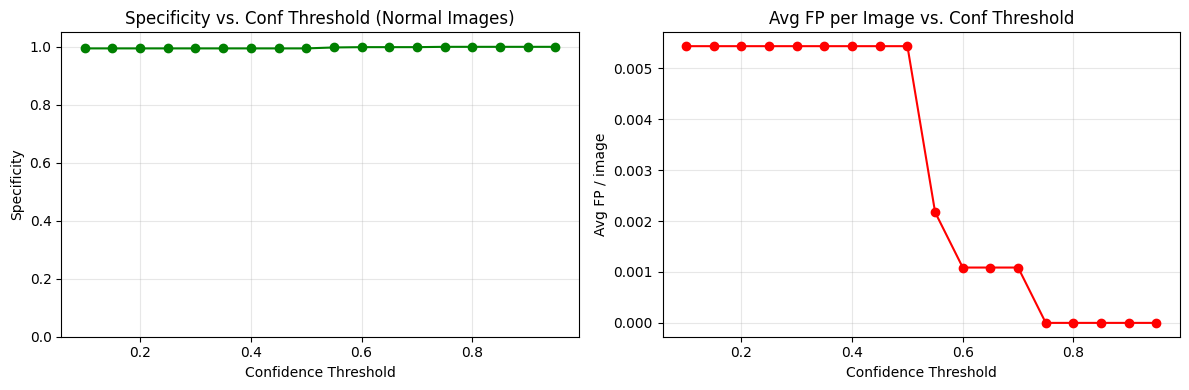

,conf_threshold,fp_images,specificity,fp_rate,total_fp,avg_fp_per_image
0,0.10,5,0.994565,0.005435,5,0.005435
1,0.15,5,0.994565,0.005435,5,0.005435
2,0.20,5,0.994565,0.005435,5,0.005435
3,0.25,5,0.994565,0.005435,5,0.005435
4,0.30,5,0.994565,0.005435,5,0.005435
5,0.35,5,0.994565,0.005435,5,0.005435
6,0.40,5,0.994565,0.005435,5,0.005435
7,0.45,5,0.994565,0.005435,5,0.005435
8,0.50,5,0.994565,0.005435,5,0.005435
9,0.55,2,0.997826,0.002174,2,0.002174


In [12]:
# 重新從 raw_results 計算不同 conf threshold 的 FP rate
thresholds = np.arange(0.1, 1.0, 0.05)
sweep_rows = []

for conf_thr in thresholds:
    n_images = len(raw_results)
    fp_images = 0
    total_fp = 0

    for image_path, pid, result in raw_results:
        if result.boxes is None or len(result.boxes) == 0:
            continue
        classes = result.boxes.cls.cpu().numpy()
        confs   = result.boxes.conf.cpu().numpy()
        nodule_preds = [(cls, c) for cls, c in zip(classes, confs)
                        if cls == 0 and c >= conf_thr]
        if len(nodule_preds) > 0:
            fp_images += 1
            total_fp  += len(nodule_preds)

    sweep_rows.append({
        'conf_threshold': round(conf_thr, 2),
        'fp_images': fp_images,
        'specificity': 1 - fp_images / n_images,
        'fp_rate': fp_images / n_images,
        'total_fp': total_fp,
        'avg_fp_per_image': total_fp / n_images,
    })

sweep_df = pd.DataFrame(sweep_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(sweep_df['conf_threshold'], sweep_df['specificity'],
             marker='o', color='green')
axes[0].set_xlabel('Confidence Threshold')
axes[0].set_ylabel('Specificity')
axes[0].set_title('Specificity vs. Conf Threshold (Normal Images)')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1.05])

axes[1].plot(sweep_df['conf_threshold'], sweep_df['avg_fp_per_image'],
             marker='o', color='red')
axes[1].set_xlabel('Confidence Threshold')
axes[1].set_ylabel('Avg FP / image')
axes[1].set_title('Avg FP per Image vs. Conf Threshold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

display(sweep_df)

# Visualize FP Images

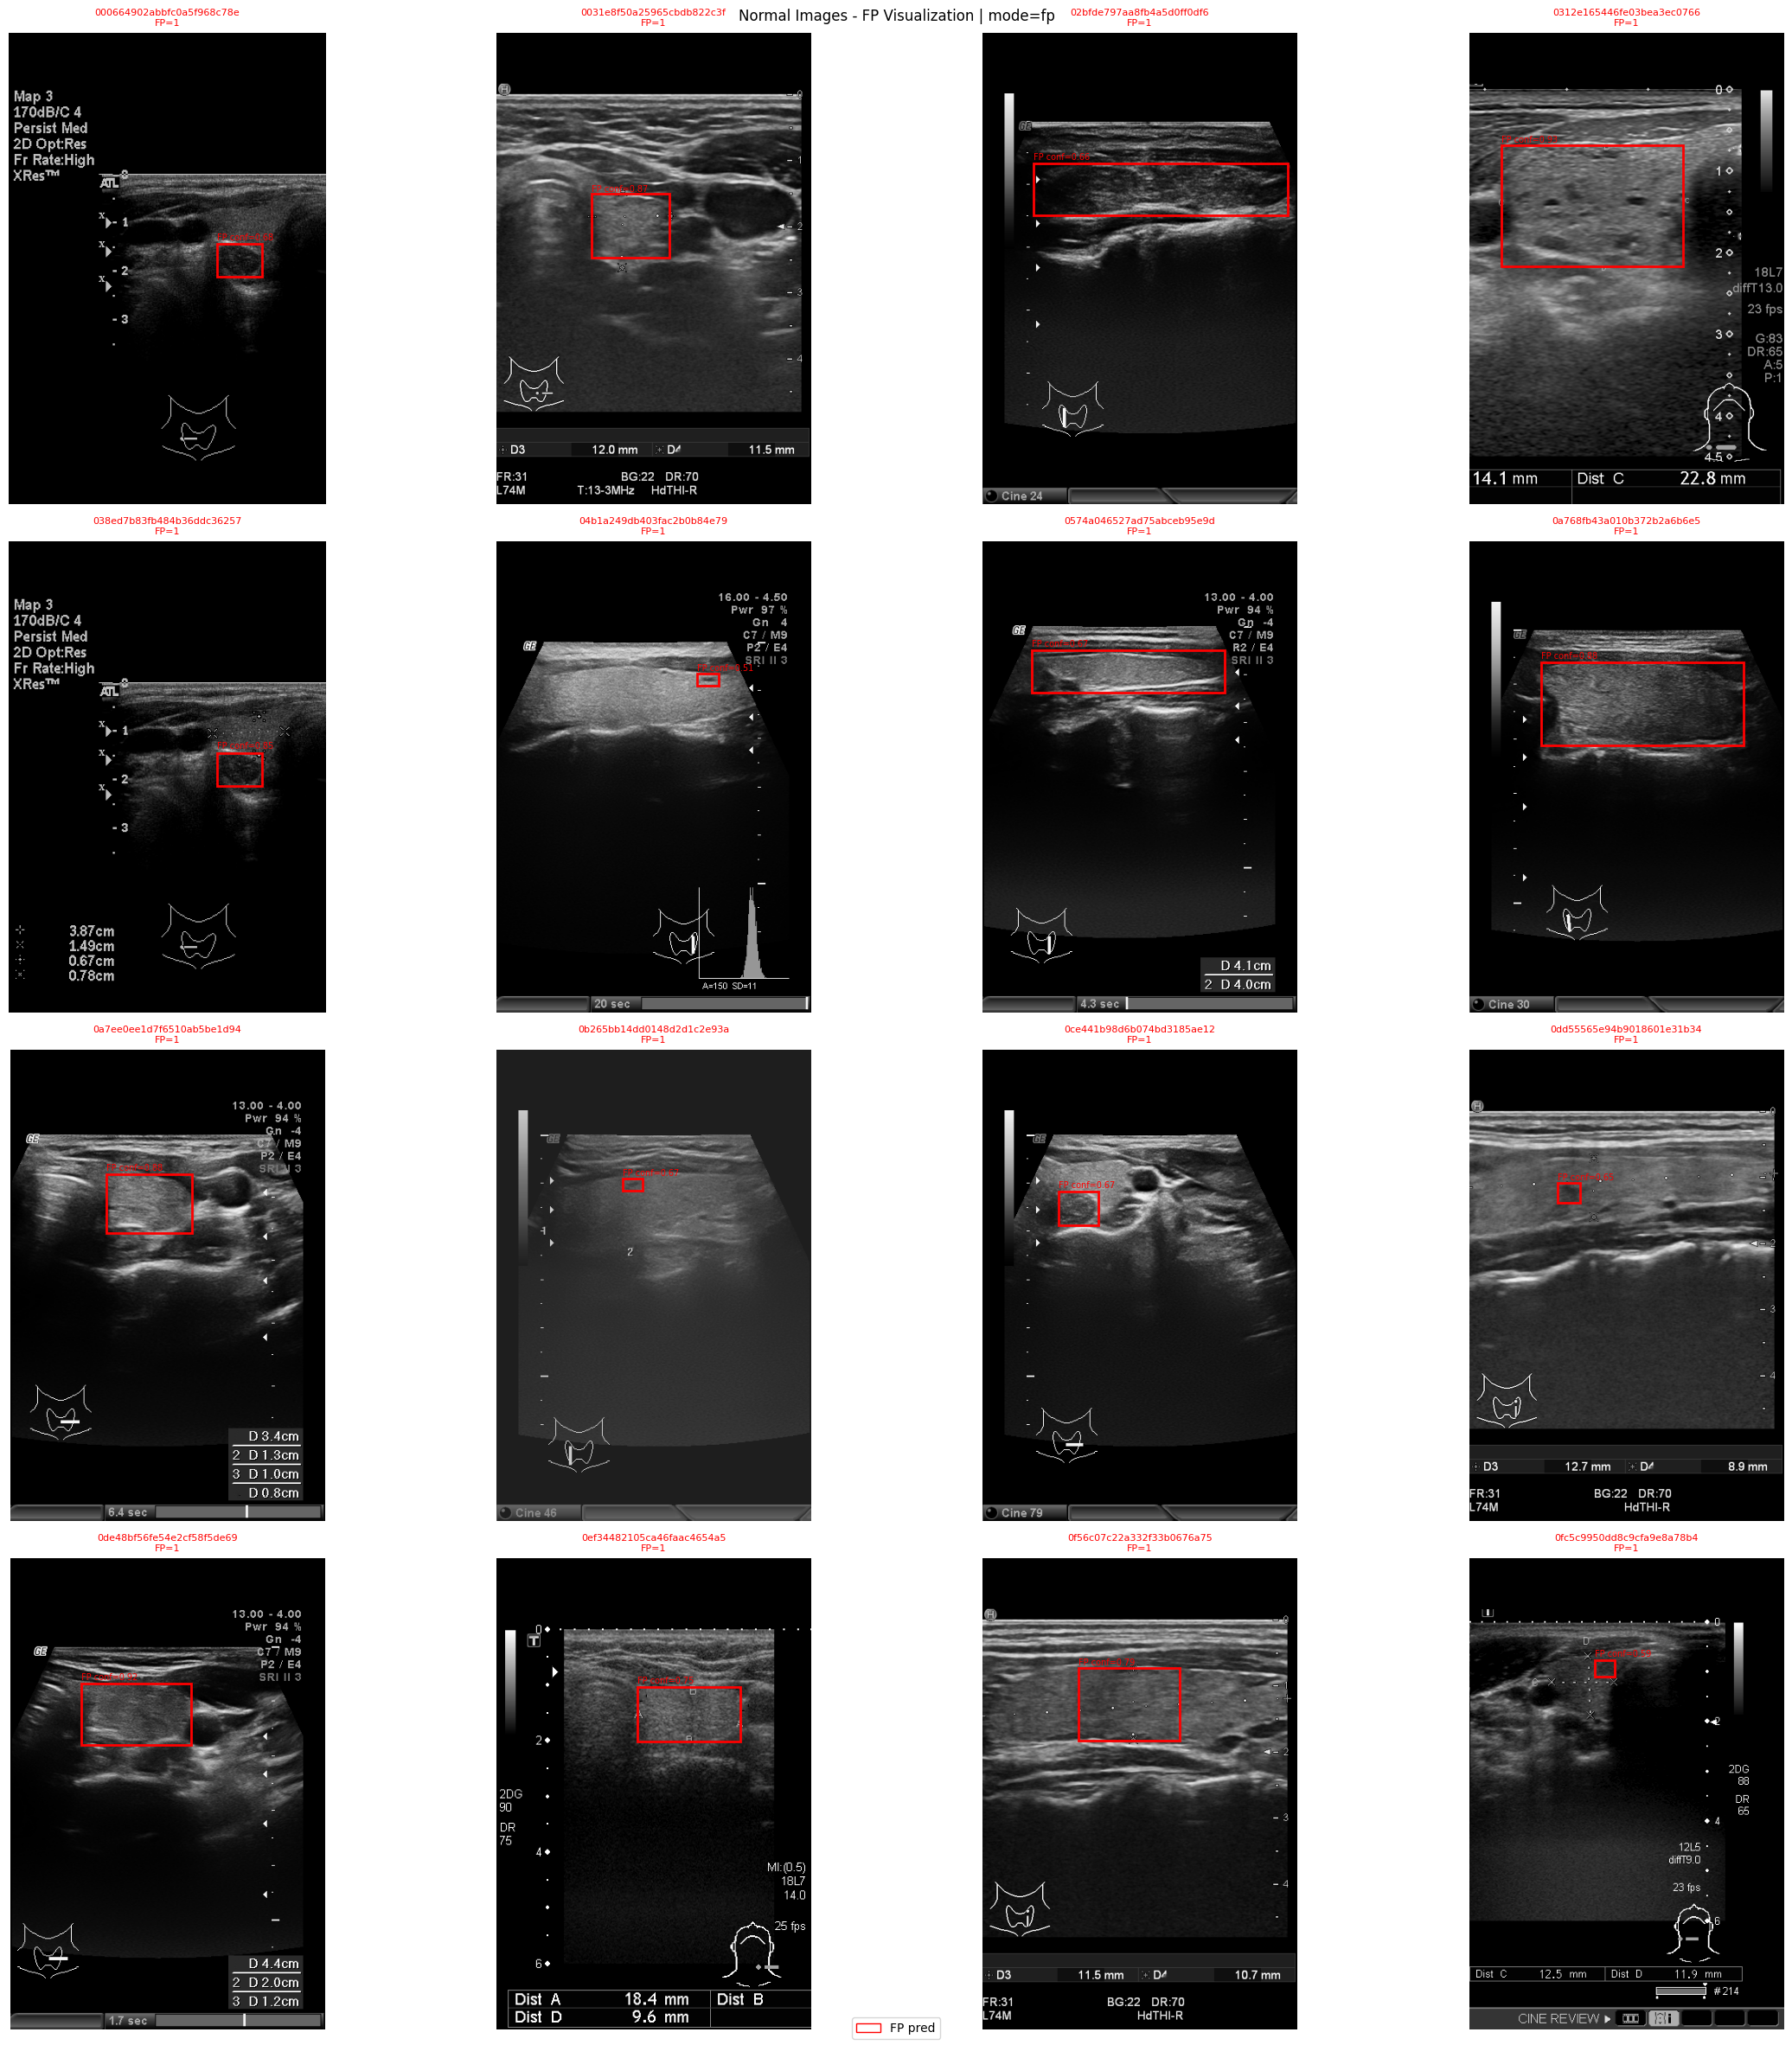

In [40]:
# 顯示 FP 最多的 16 張圖片
visualize_fp_samples(normal_result_df, data_root, n=16, mode='fp')

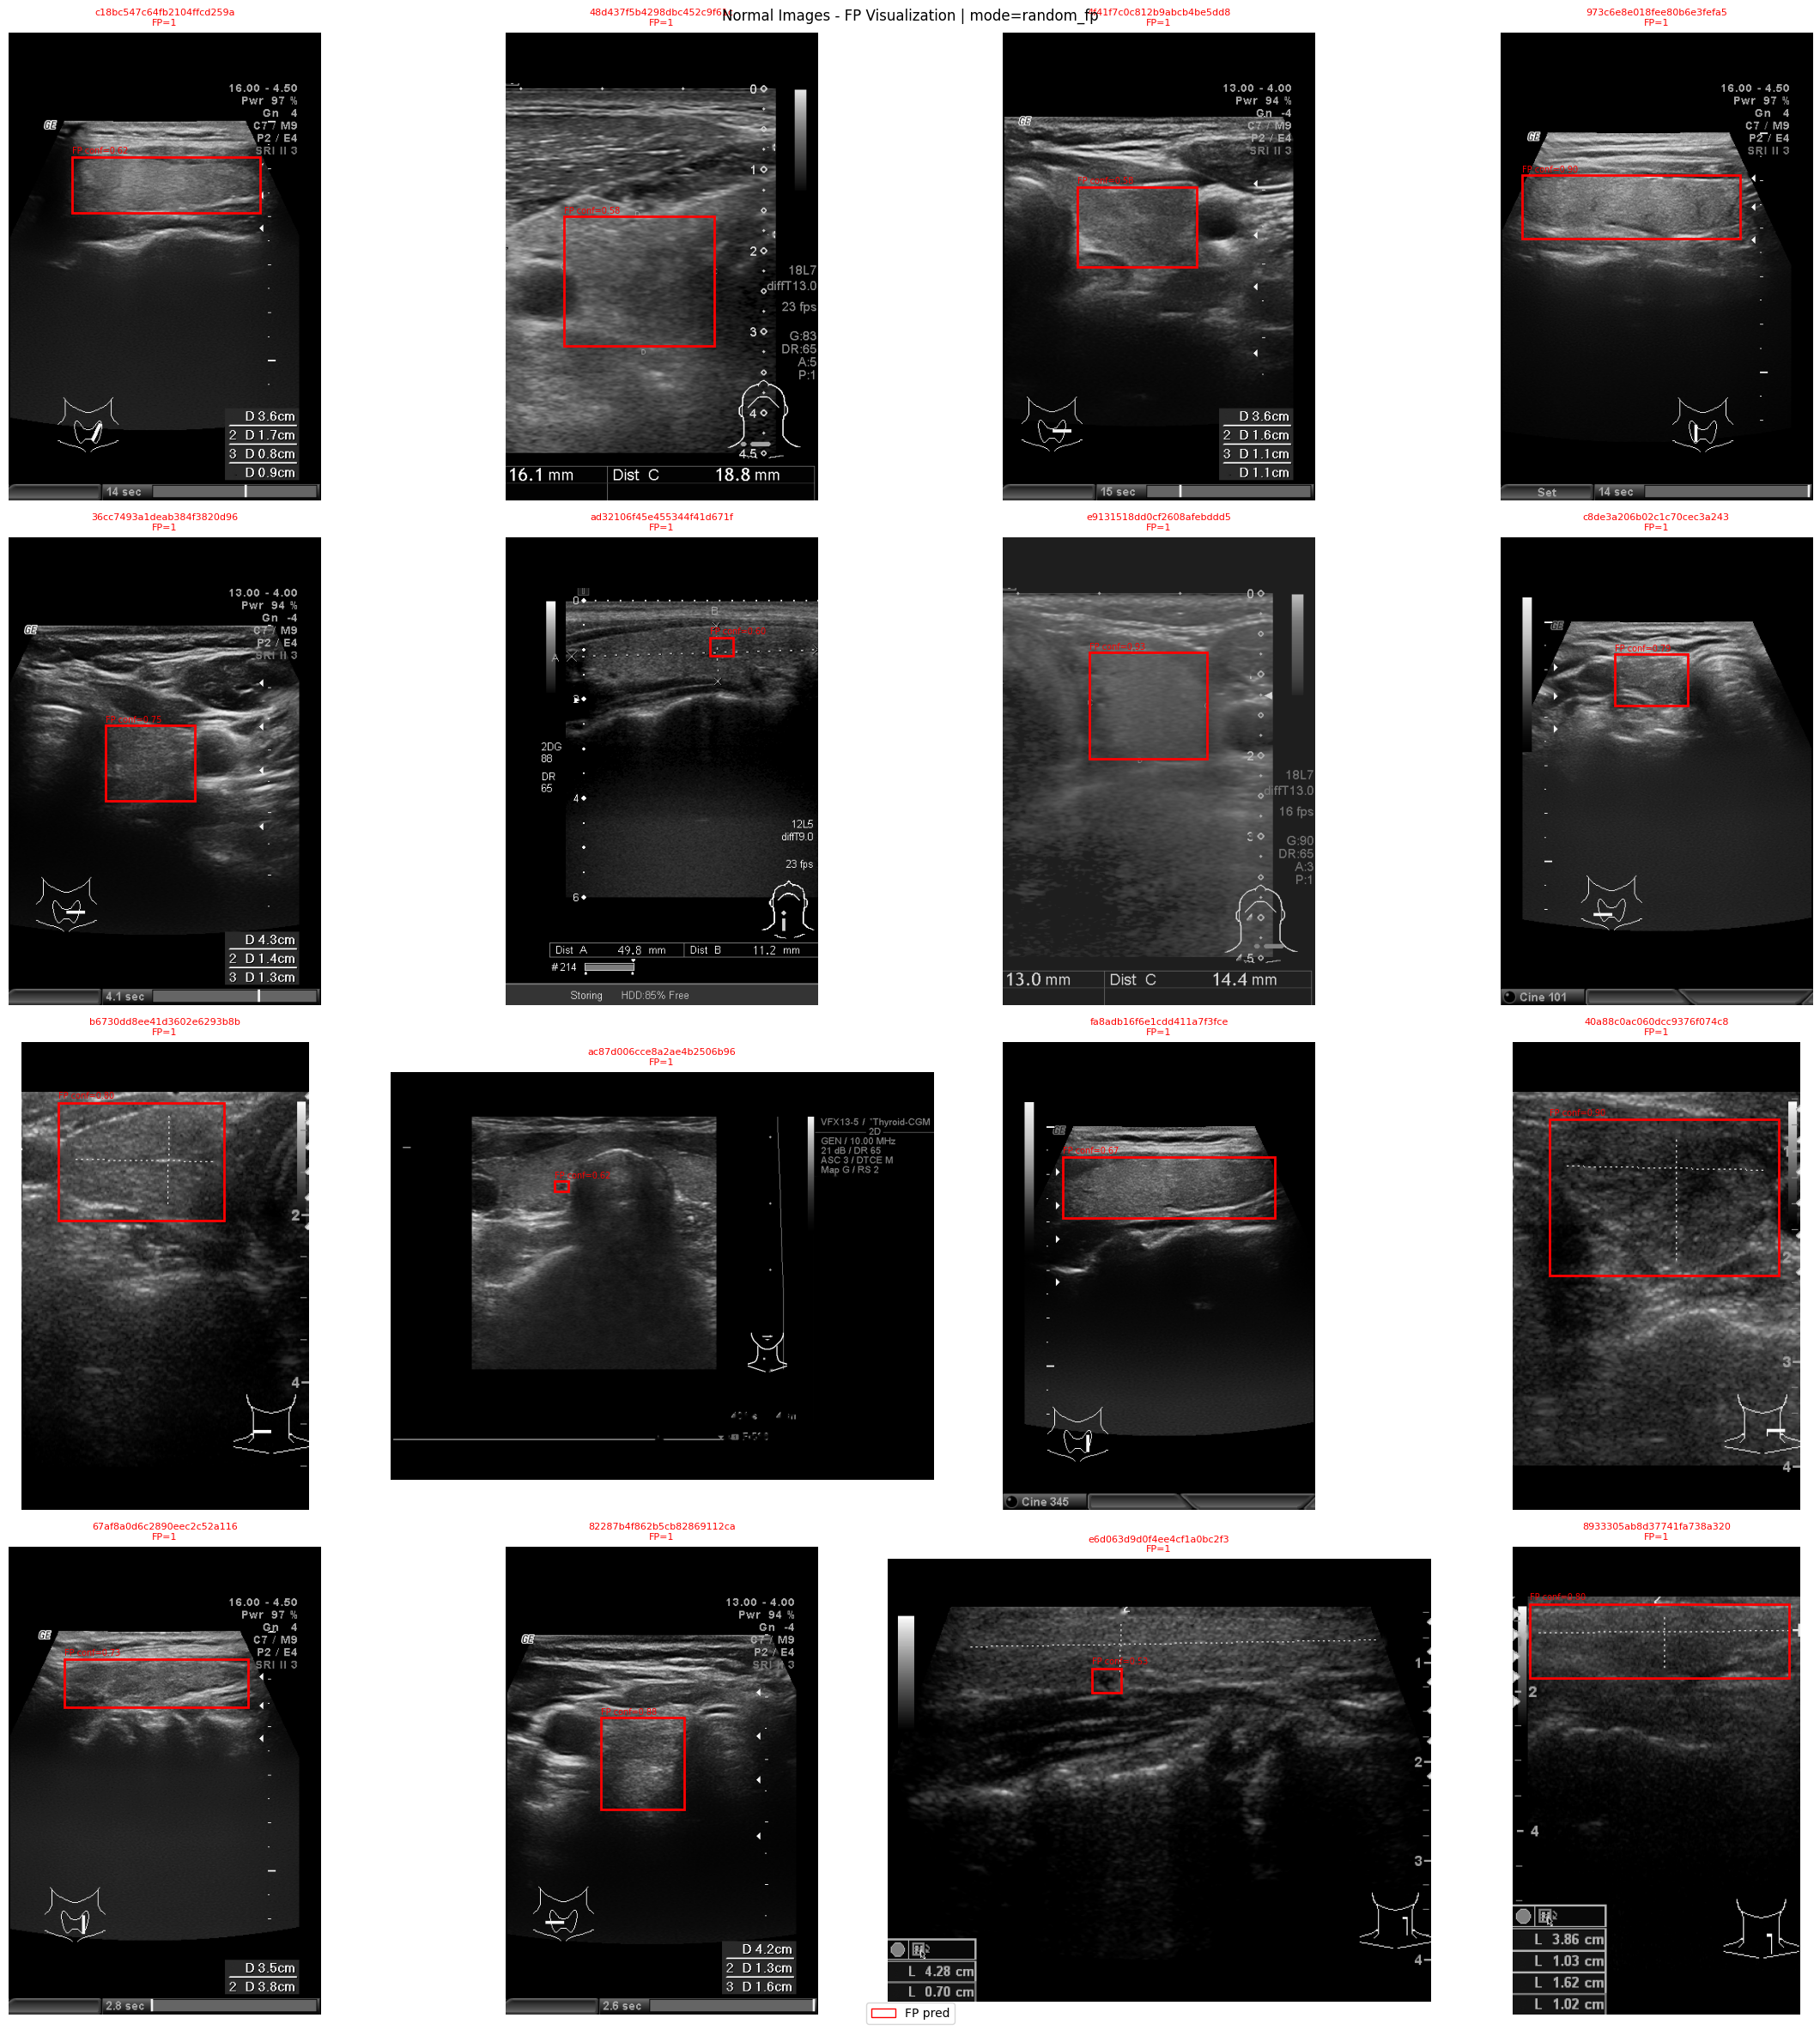

In [32]:
# 隨機顯示有 FP 的圖片
visualize_fp_samples(normal_result_df, data_root, n=16, mode='random_fp')

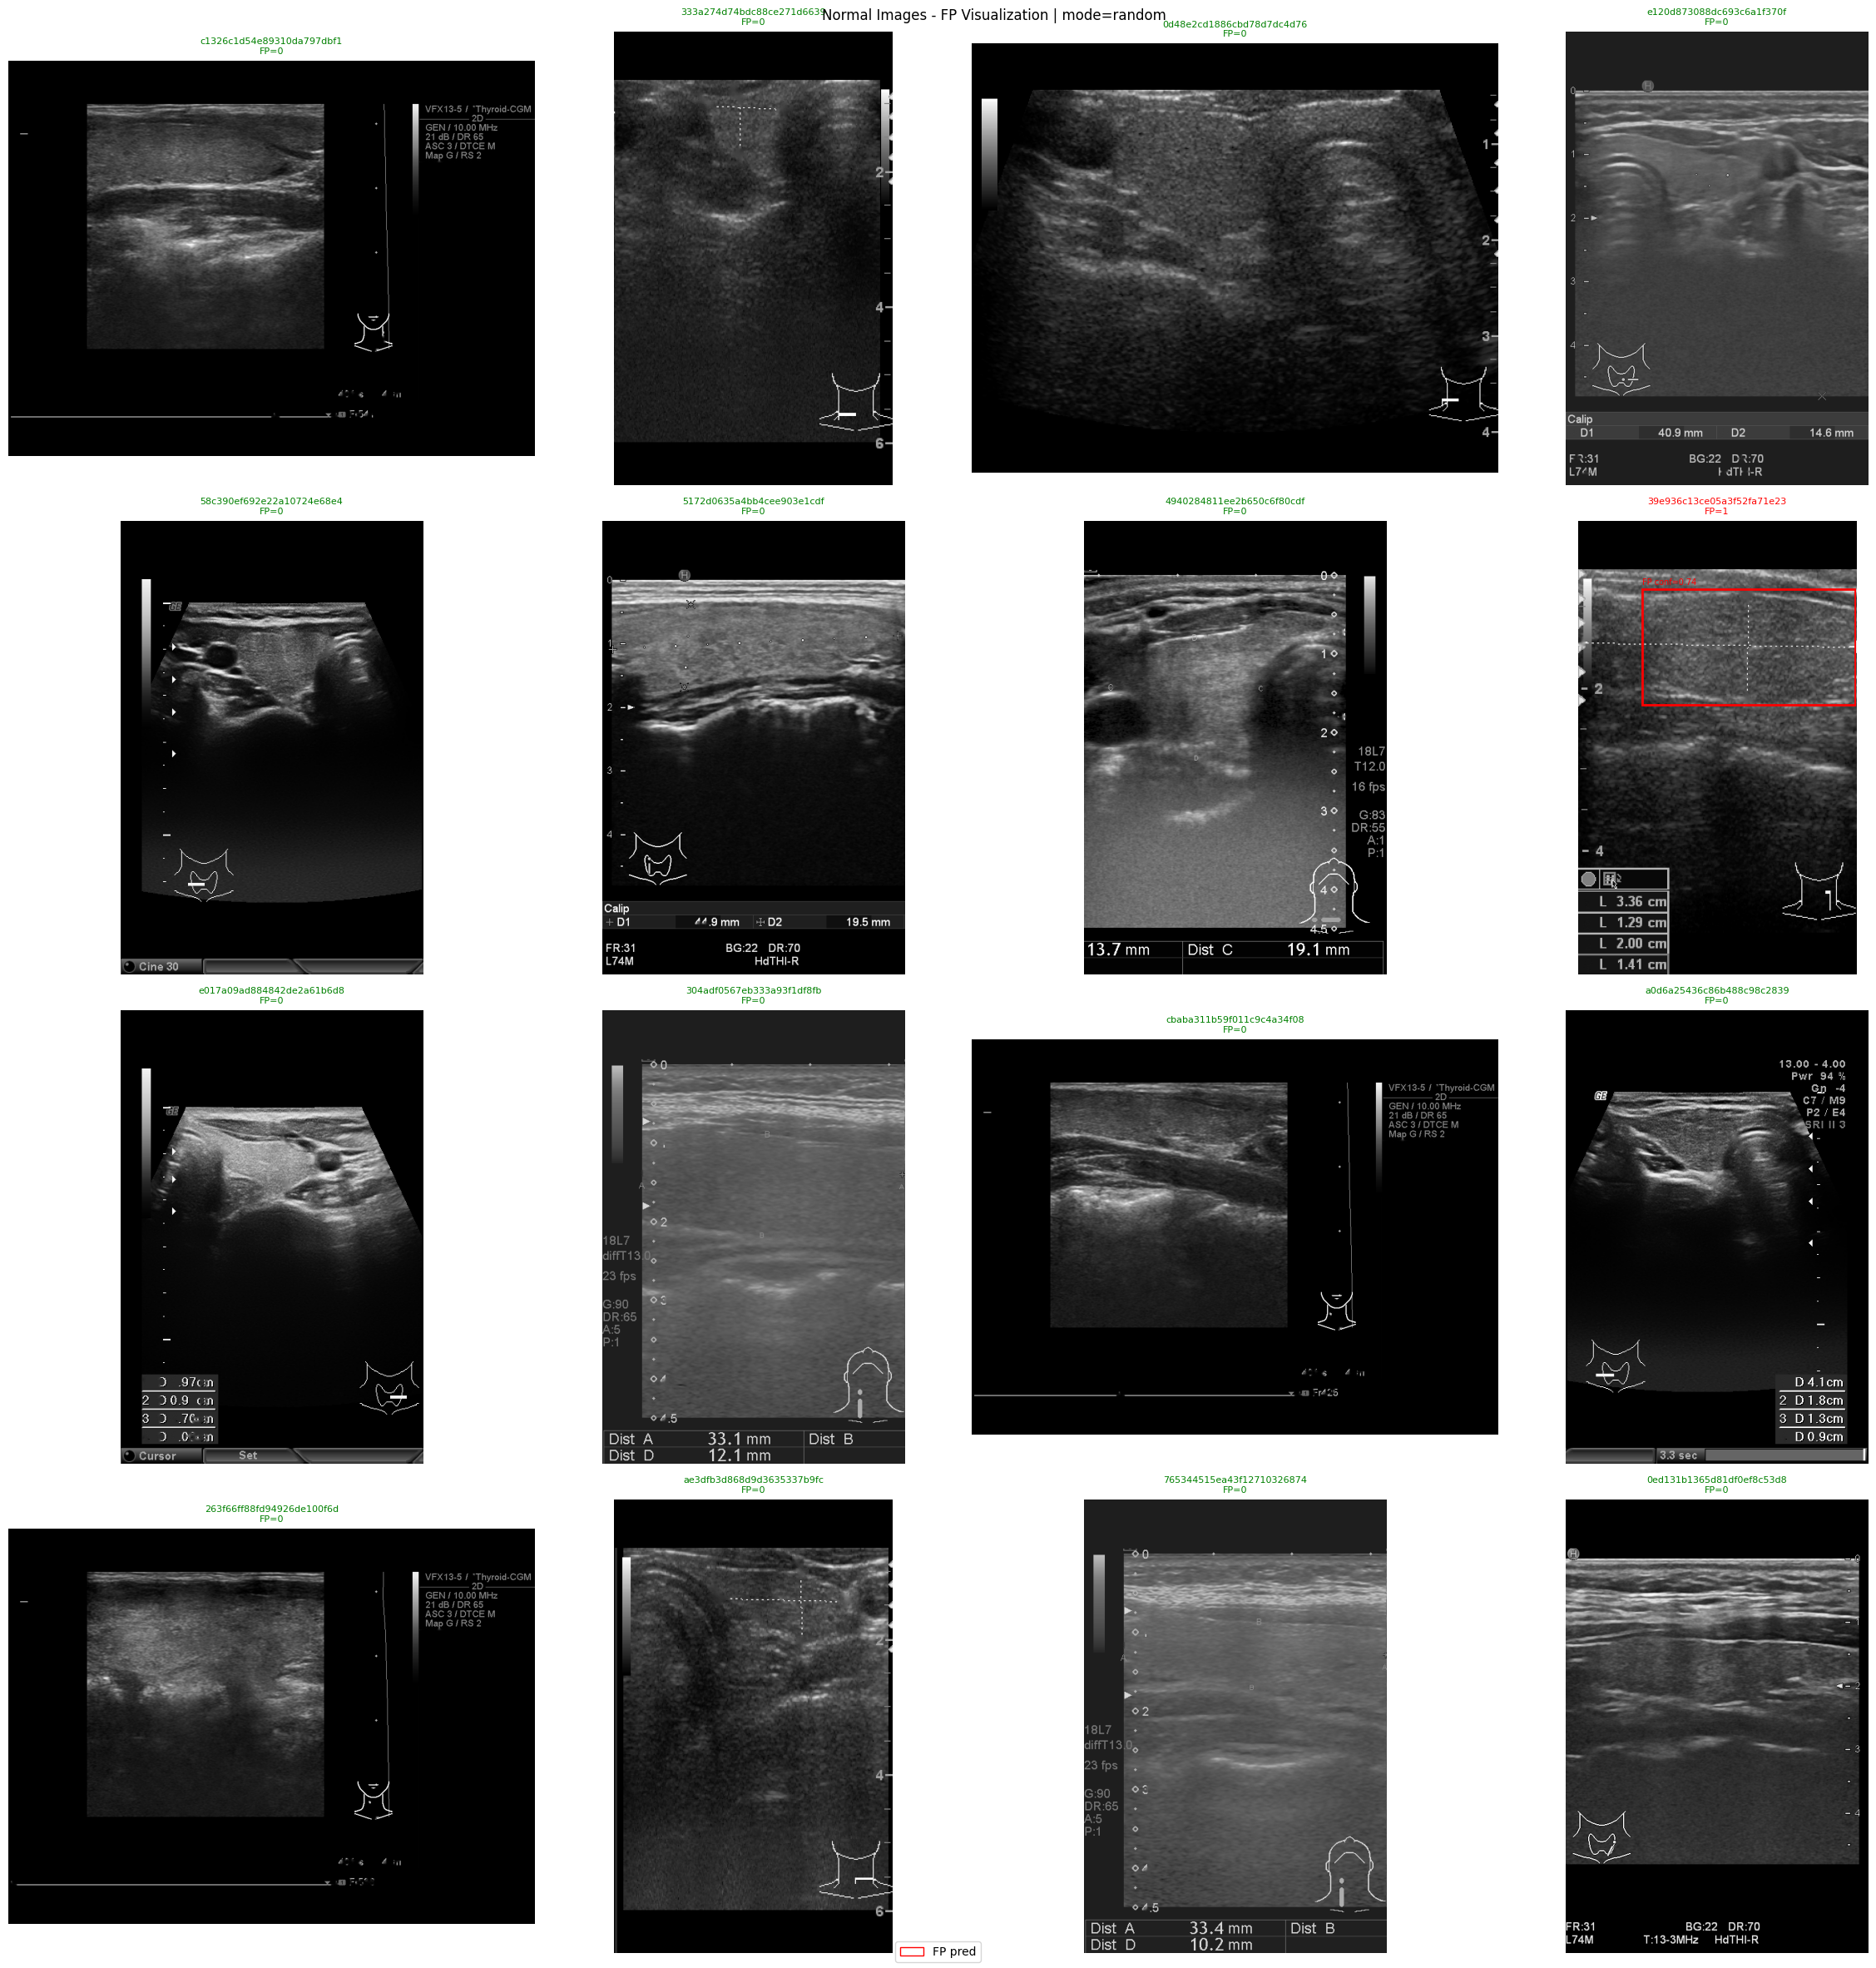

In [33]:
# 隨機顯示所有 normal 圖片（含 TN 與 FP）
visualize_fp_samples(normal_result_df, data_root, n=16, mode='random')

# Save Results

In [ ]:
save_dir = f"../yolo_output/runs/detect/{name}"
os.makedirs(save_dir, exist_ok=True)

# 詳細記錄
normal_result_df.to_csv(f"{save_dir}/normal_fp_records.csv", index=False)

# Threshold sweep
sweep_df.to_csv(f"{save_dir}/normal_conf_sweep.csv", index=False)

# 彙整指標
metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv(f"{save_dir}/normal_metrics.csv", index=False)

print(f"Results saved to {save_dir}")